In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

import sys
sys.path.append("/mnt/d/Users/Admin/Projects/dso/learnable_polyphase_sampling/learn_poly_sampling")

from functools import partial
from layers import PolyphaseInvariantDown2D, LPS, get_logits_model
from models.resnet_custom import ResNet18Custom

In [2]:
get_logits = get_logits_model('LPSLogitLayers')
pooling_layer = partial(PolyphaseInvariantDown2D, component_selection=LPS, get_logits=get_logits)

extras_model = {
    'logits_channels': {"maxpool": 8, "layer2": 16, "layer3": 32, "layer4": 64},
    'conv1_stride': False,
    'maxpool_zpad': False,
    'swap_conv_pool': True,
    'inc_conv1_support': True,
    'apply_maxpool': True,
    'ret_prob': True,
    'forward_pool_method': 'LPS',
}

their_model = ResNet18Custom(
    input_shape=(3, 128, 128),
    num_classes=10,
    padding_mode='circular',
    pooling_layer=pooling_layer,
    extras_model=extras_model,
)
print(their_model)

[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
ResNet18Custom(
  (core): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False, padding_mode=circular)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): Sequential(
      (0): PolyphaseInvariantDown2D(
        (component_selection): LPS(
          (get_logits): LPSLogitLayersV2(
            (conv1): Conv2d(64, 8, kernel_size=(3, 3), stride=(1, 1), padding=same, padding_mode=circular)
            (conv2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=same, padding_mode=circular)
            (relu): ReLU()
          )
        )
      )
      (1): cpad(pad=[0, 1, 0, 1])
      (2): MaxPool2d

In [3]:
their_model = their_model.eval().double()
x = torch.randn(2, 3, 128, 128).double()
with torch.no_grad():
    y_orig = their_model.core(x)  # .core to bypass Lightning's forward()'s log_softmax, or use their_model(x) directly since it applies log_softmax too
    x_roll = torch.roll(x, shifts=(10, 10), dims=(-1, -2))
    y_roll = their_model.core(x_roll)
print(torch.norm(y_orig - y_roll).item())

7.36354950294357e-15


In [4]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [5]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [6]:
meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [7]:
train_ds = filter_by_elev(meas_ds, {14, 15, 16})
test_ds = filter_by_elev(meas_ds, {17})
valid_ds = test_ds # used to see the acc and loss curve for the test_ds, not used for selecting what model is the best

ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

In [8]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
 
train_loss = []
val_loss = []
train_acc = []
val_acc = []
 
for i, seed in enumerate(seed_lst):
    
    start = time.perf_counter()
    
    print(f"Training Run {i}: seed {seed}")
    set_seed(seed)
 
    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
    get_logits = get_logits_model('LPSLogitLayers')
    pooling_layer = partial(PolyphaseInvariantDown2D, component_selection=LPS, get_logits=get_logits)
    extras_model = {
        'logits_channels': {"maxpool": 8, "layer2": 16, "layer3": 32, "layer4": 64},
        'conv1_stride': False,
        'maxpool_zpad': False,
        'swap_conv_pool': True,
        'inc_conv1_support': True,
        'apply_maxpool': True,
        'ret_prob': True,
        'forward_pool_method': 'LPS',
    }
    
    model = ResNet18Custom(
        input_shape=(3, 128, 128),
        num_classes=len(train_ds.class_to_idx),
        padding_mode='circular',
        pooling_layer=pooling_layer,
        extras_model=extras_model,
    )
 
    # Define the loss function and optimizer
    criterion = nn.NLLLoss()

    net_pars, pool_pars = [], []
    for n, p in model.named_parameters():
        if "component_selection" in n and p.requires_grad:
            pool_pars.append(p)
        elif p.requires_grad:
            net_pars.append(p)
            
    optimizer = optim.AdamW([
        {"params": net_pars, "weight_decay": 2e-4},
        {"params": pool_pars, "weight_decay": 0},
    ], lr=3e-4)
    
    scheduler = CosineAnnealingLR(optimizer, T_max=200, eta_min=3e-7)
    
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
 
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }
 
    # Training loop
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.core.conv1.weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
 
            running_loss = 0.0
            running_corrects = 0
 
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
 
                optimizer.zero_grad()
 
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
 
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
 
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
 
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
 
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
 
            print(f"{phase} Loss: {epoch_loss:.10f} Acc: {epoch_acc:.10f}")
 
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
 
    print("Training complete!")
 
    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    val_acc.append(history["val_acc"])
 
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/LPD/real/rn18_seed{seed}_b16_theirmodel.pth"))
    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")
 
train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
val_acc = np.array(val_acc)

Training Run 0: seed 10
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Epoch 0
First layer mean: 0.000035
train Loss: 1.8301994395 Acc: 0.3573200993
val Loss: 2.5973917345 Acc: 0.3153988868
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 0.9435375836 Acc: 0.6861042184
val Loss: 2.5894989804 Acc: 0.3395176252
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 0.5349512720 Acc: 0.8238213400
val Loss: 3.1886357203 Acc: 0.3525046382
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 0.3443128948 Acc: 0.8995037221
val Loss: 1.1787380372 Acc: 0.6437847866
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.1743725743 Acc: 0.9503722084
val Loss: 0.8645021665 Acc: 0.7569573284
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.1833799445 Acc: 0.9429280397
val Loss: 0.9371918626 Acc: 0.6734693878
Epoch 5

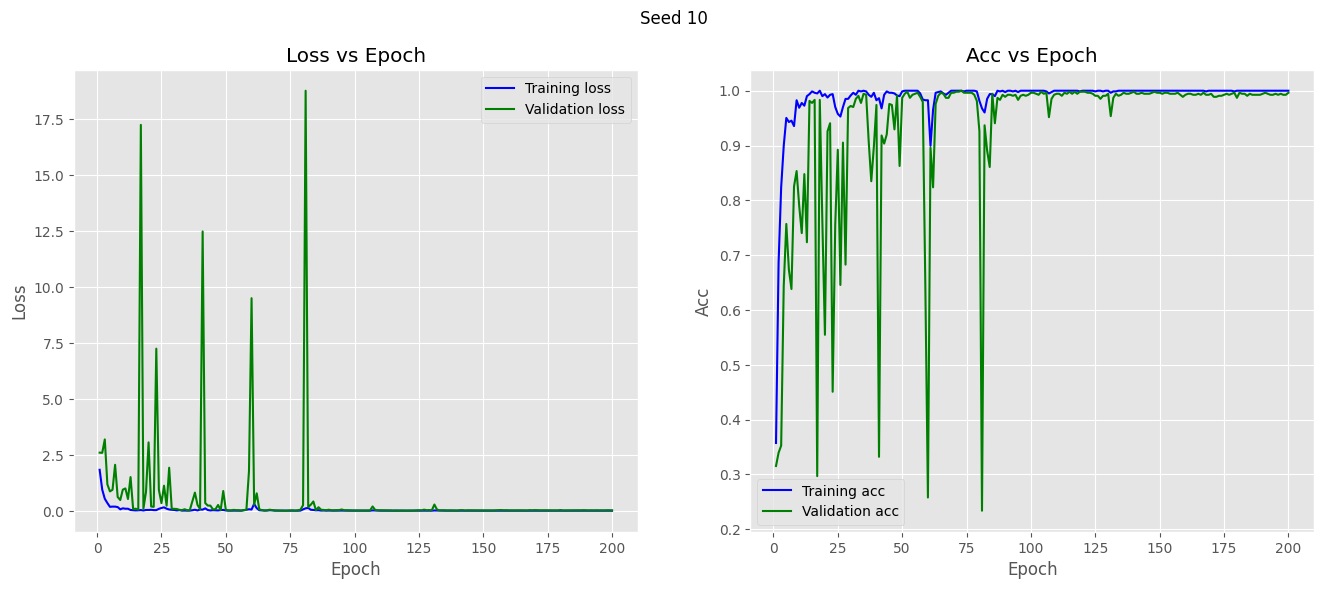

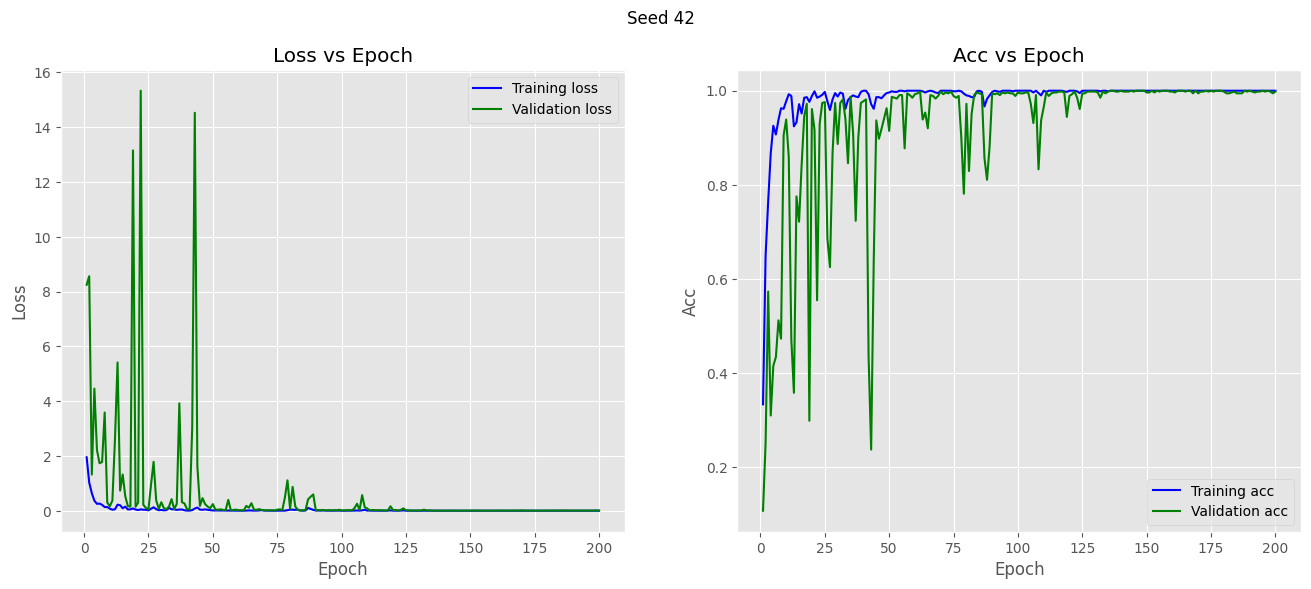

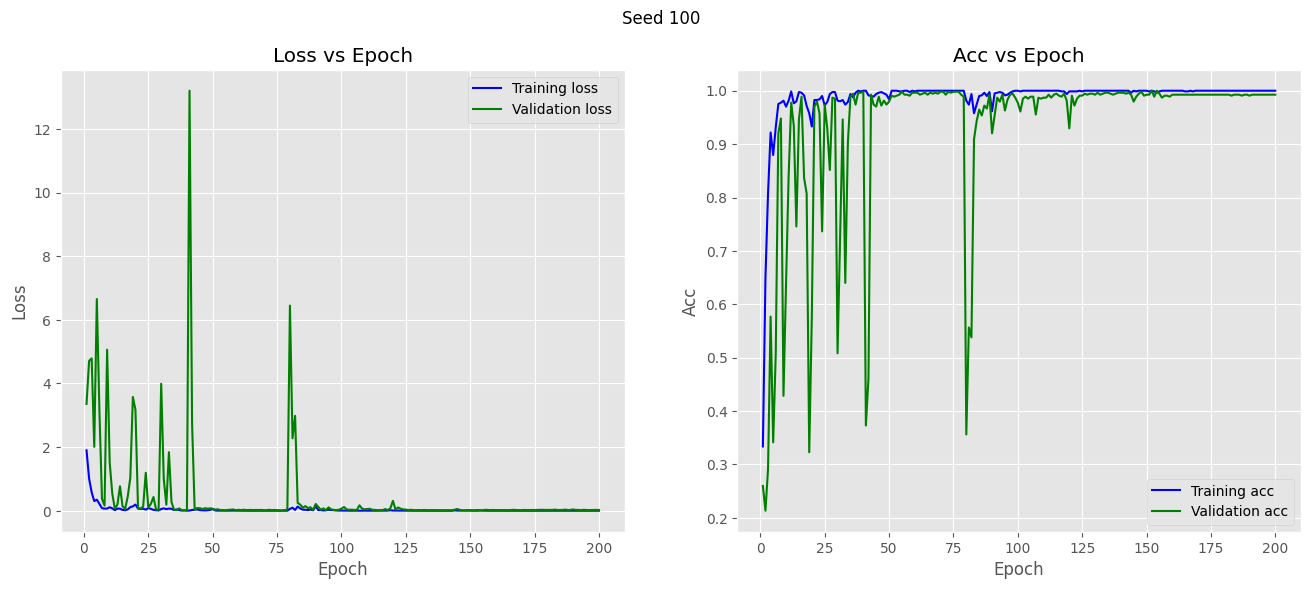

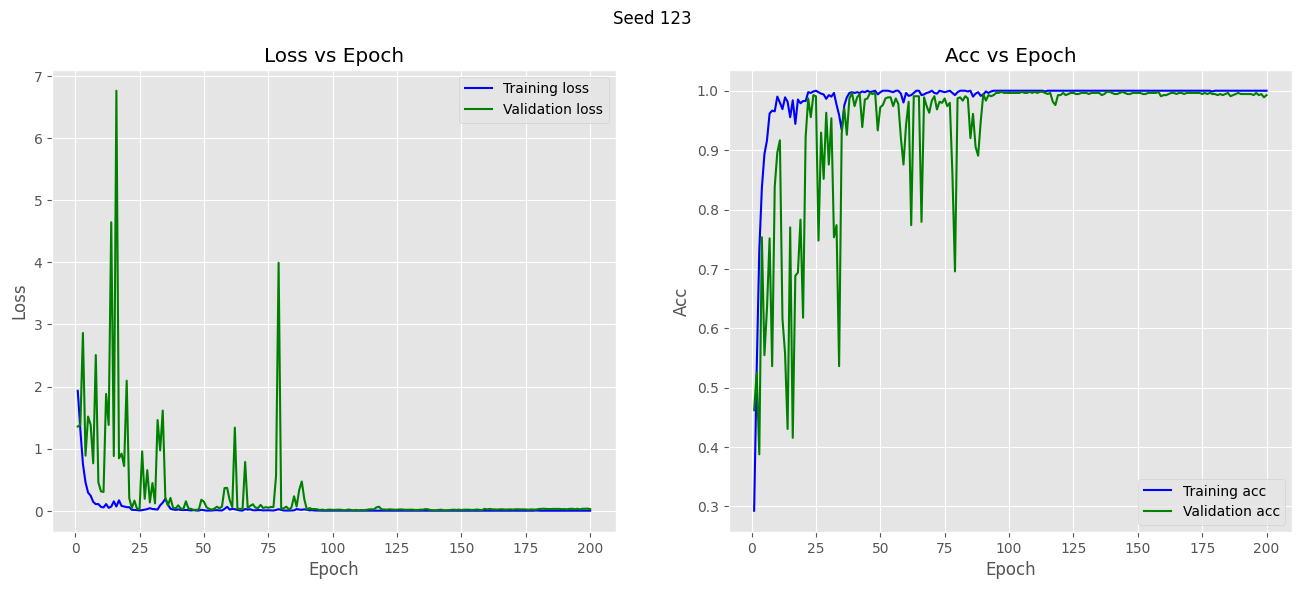

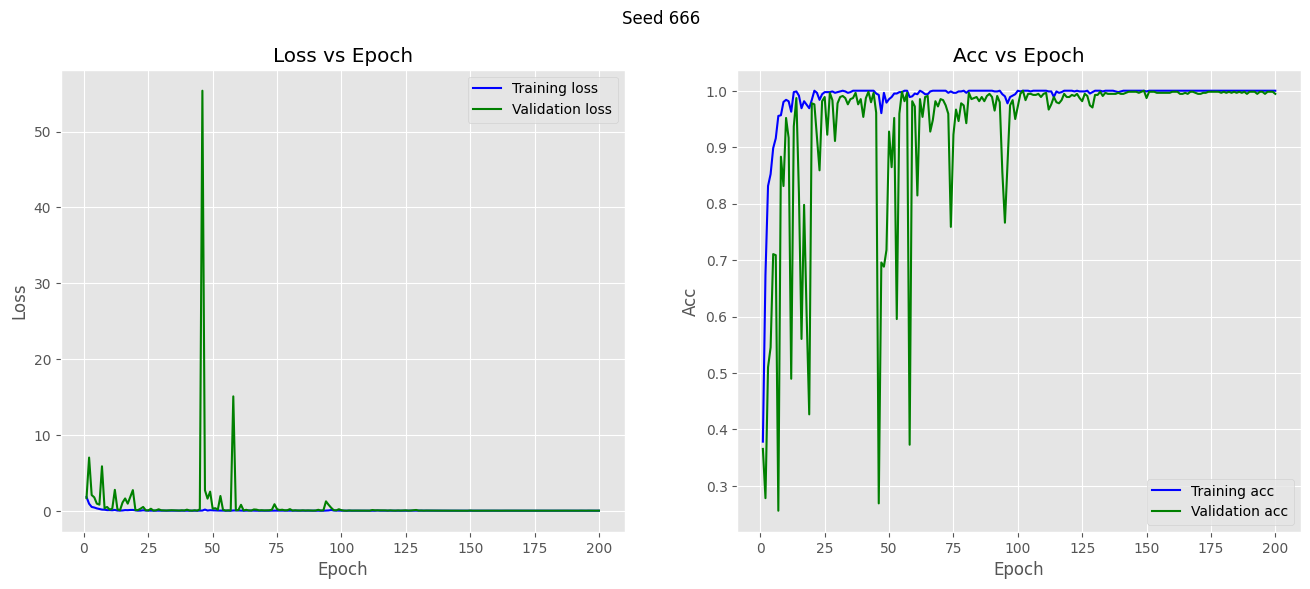

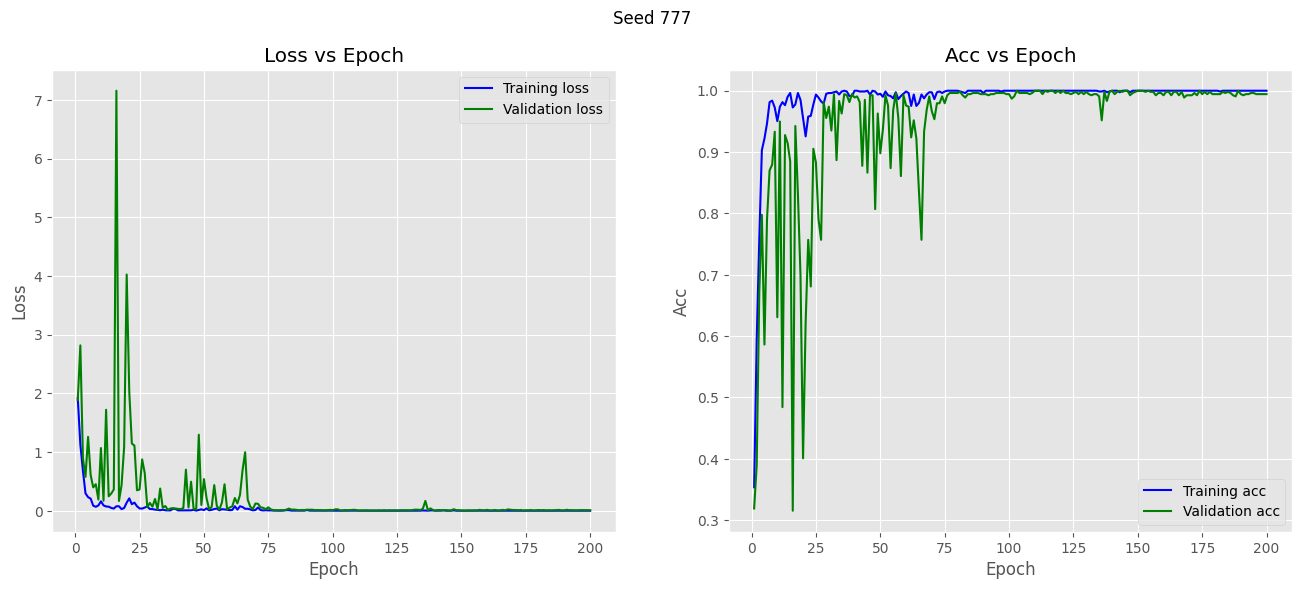

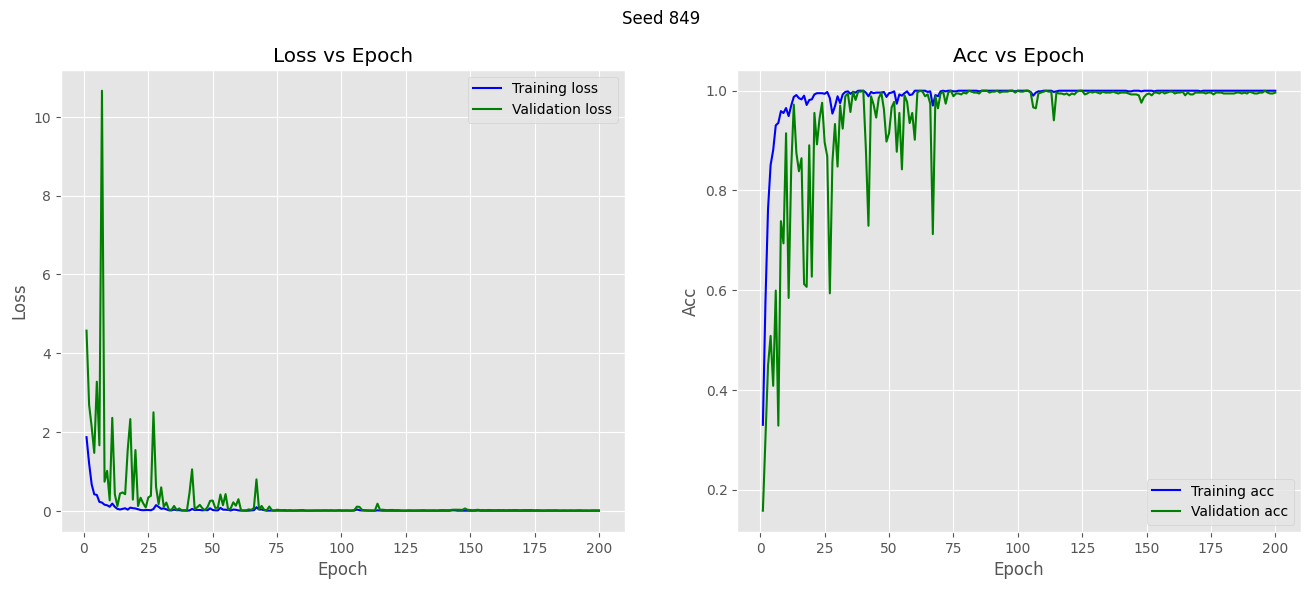

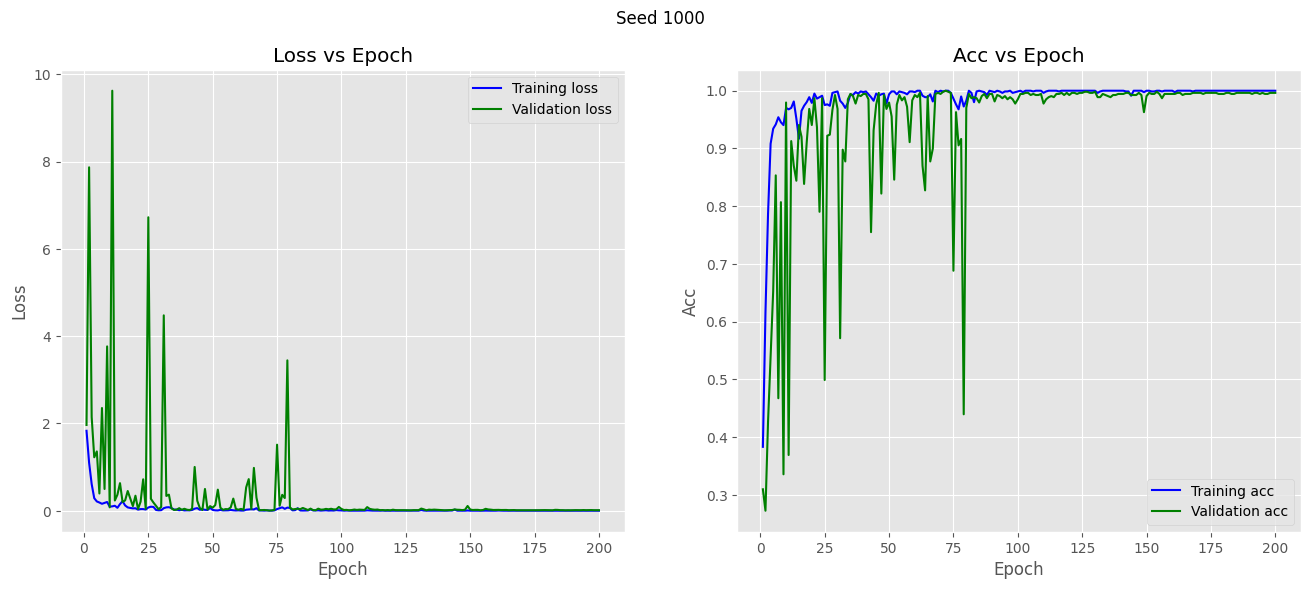

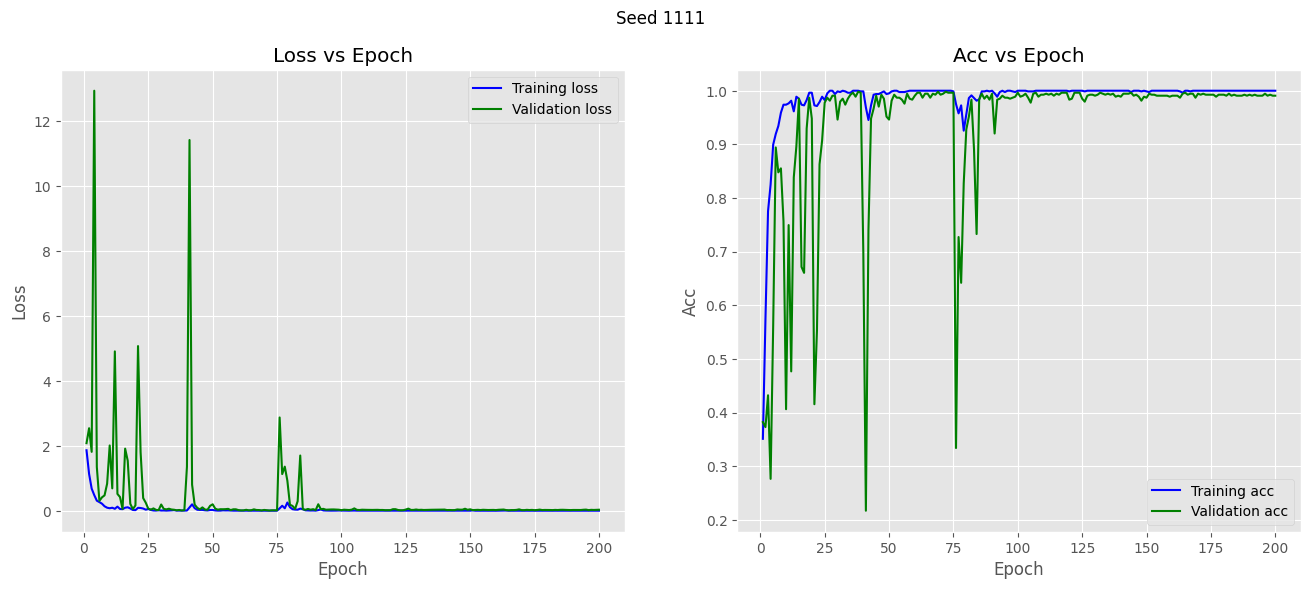

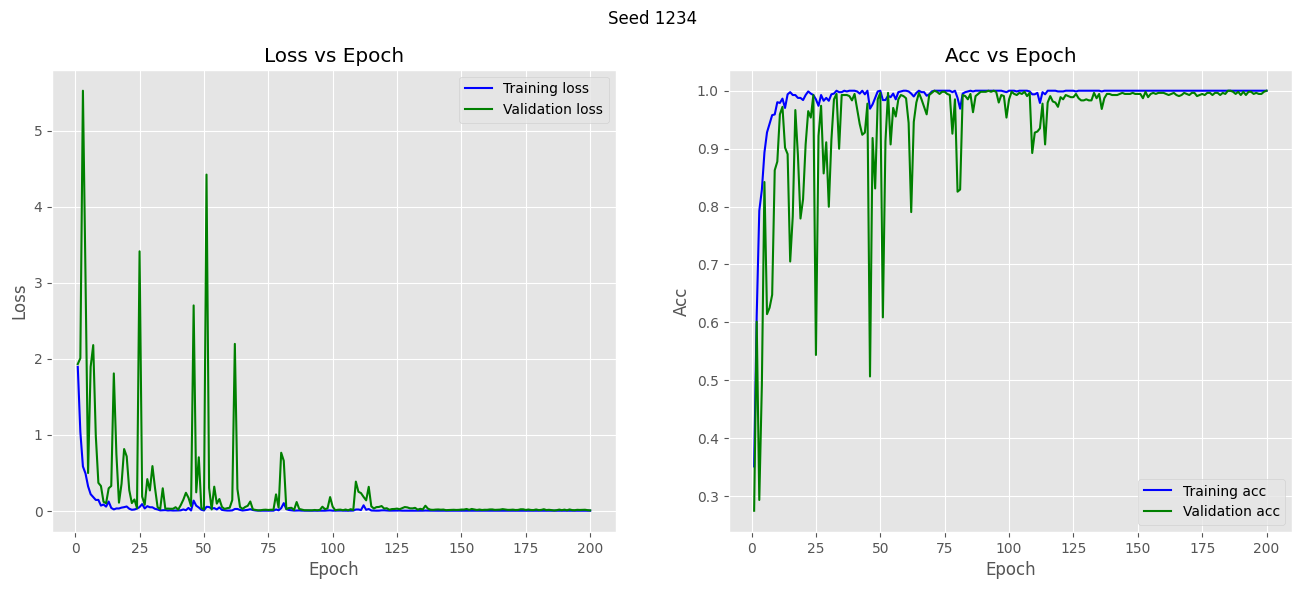

In [9]:
row, col = train_loss.shape

for i, seed in enumerate(seed_lst):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (16, 6))
    
        ax0 = fig.add_subplot(1, 2, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 2, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Acc")
        ax1.legend()
        ax1.grid(True)

        fig.suptitle(f"Seed {seed}")
        plt.show()

In [10]:
shifted_left_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = -5, axis = -1), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_right_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = 15, axis = -1), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_up_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = 10, axis = -2), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_down_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = -10, axis = -2), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

shifted_left_17 = filter_by_elev(shifted_left_meas_ds, {17})
shifted_right_17 = filter_by_elev(shifted_right_meas_ds, {17})
shifted_up_17 = filter_by_elev(shifted_up_meas_ds, {17})
shifted_down_17 = filter_by_elev(shifted_down_meas_ds, {17})

In [15]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    
    get_logits = get_logits_model('LPSLogitLayers')
    pooling_layer = partial(PolyphaseInvariantDown2D, component_selection=LPS, get_logits=get_logits)
    extras_model = {
        'logits_channels': {"maxpool": 8, "layer2": 16, "layer3": 32, "layer4": 64},
        'conv1_stride': False,
        'maxpool_zpad': False,
        'swap_conv_pool': True,
        'inc_conv1_support': True,
        'apply_maxpool': True,
        'ret_prob': True,
        'forward_pool_method': 'LPS',
    }
    
    new_model = ResNet18Custom(
        input_shape=(3, 128, 128),
        num_classes=len(train_ds.class_to_idx),
        padding_mode='circular',
        pooling_layer=pooling_layer,
        extras_model=extras_model,
    )
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/LPD/real/rn18_seed{seed}_b16_theirmodel.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {100*test_acc:.4f}")
    test_acc_lst.append(test_acc)

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0: Seed 10
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Test Accuracy: 99.6289
Evaluating Run 1: Seed 42
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Test Accuracy: 99.8145
Evaluating Run 2: Seed 100
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Test Accuracy: 99.2579
Evaluating Run 3: Seed 123
[ResNet18Custom] self.maxpool_

In [14]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")

    get_logits = get_logits_model('LPSLogitLayers')
    pooling_layer = partial(PolyphaseInvariantDown2D, component_selection=LPS, get_logits=get_logits)
    extras_model = {
        'logits_channels': {"maxpool": 8, "layer2": 16, "layer3": 32, "layer4": 64},
        'conv1_stride': False,
        'maxpool_zpad': False,
        'swap_conv_pool': True,
        'inc_conv1_support': True,
        'apply_maxpool': True,
        'ret_prob': True,
        'forward_pool_method': 'LPS',
    }
    
    new_model = ResNet18Custom(
        input_shape=(3, 128, 128),
        num_classes=len(train_ds.class_to_idx),
        padding_mode='circular',
        pooling_layer=pooling_layer,
        extras_model=extras_model,
    )
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/LPD/real/rn18_seed{seed}_b16_theirmodel.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()
    
    for ds in [test_ds, shifted_left_17, shifted_right_17, shifted_up_17, shifted_down_17]:

        if ds is shifted_left_17:
            print("shifted left by 5 units")
        elif ds is shifted_right_17:
            print("shifted right by 15 units")
        elif ds is shifted_up_17:
            print("shifted up by 10 units")
        elif ds is shifted_down_17:
            print("shifted down by 10 units")
        elif ds is test_ds:
            print("unshifted")
        
        new_model = new_model.to(device)
        new_model.eval()
        
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in DataLoader(ds, batch_size=32, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
                inputs = inputs.to(device)
                labels = labels.to(device)
        
                outputs = new_model(inputs)
                _, preds = torch.max(outputs, 1)
        
                correct += torch.sum(preds == labels).item()
                total += labels.size(0)
        
        test_acc = correct / total
        print(f"Test Accuracy: {100*test_acc:.4f}")
        test_acc_lst.append(test_acc)
    print("\n")

Evaluating Run 0: Seed 10
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
unshifted
Test Accuracy: 99.6289
shifted left by 5 units
Test Accuracy: 99.6289
shifted right by 15 units
Test Accuracy: 99.6289
shifted up by 10 units
Test Accuracy: 99.6289
shifted down by 10 units
Test Accuracy: 99.6289


Evaluating Run 1: Seed 42
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
unshifted
Test Accuracy: 99.8145
shifted left by 5 units
Test Accuracy: 99.8145
shifted right by 15 units
Test Accuracy: 99.8145
shifted up by 10 units
Test Accuracy: 99.8145
shifted down by 10

unshifted
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)


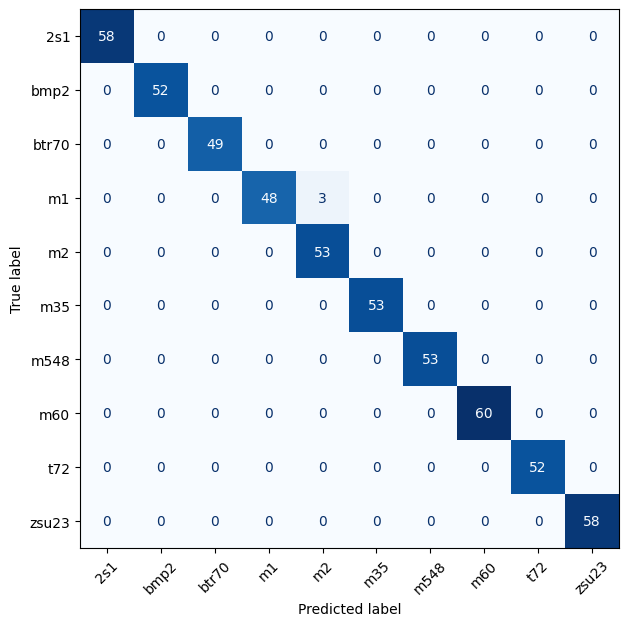

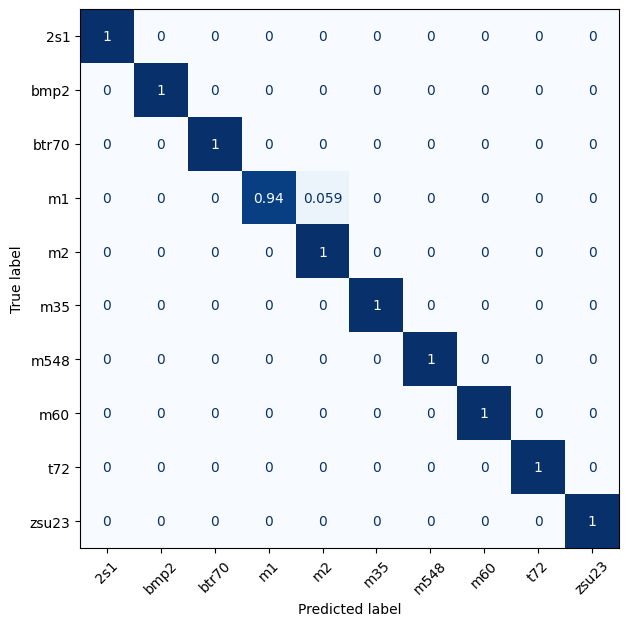

shifted left by 5 units
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)


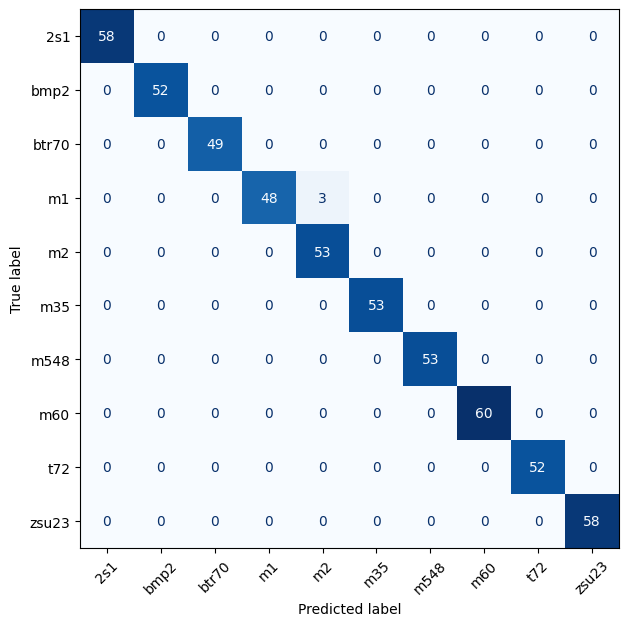

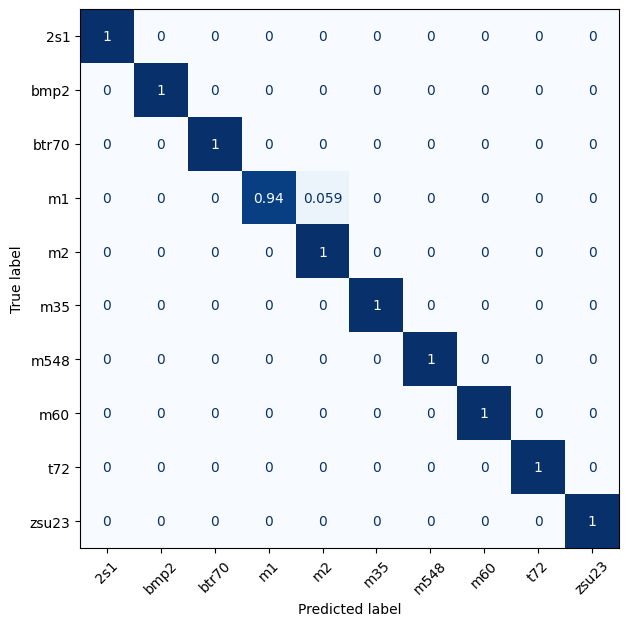

shifted right by 15 units
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)


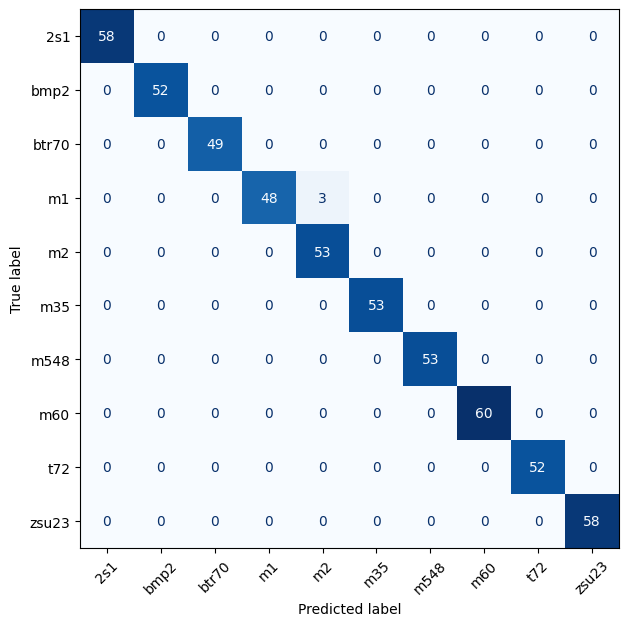

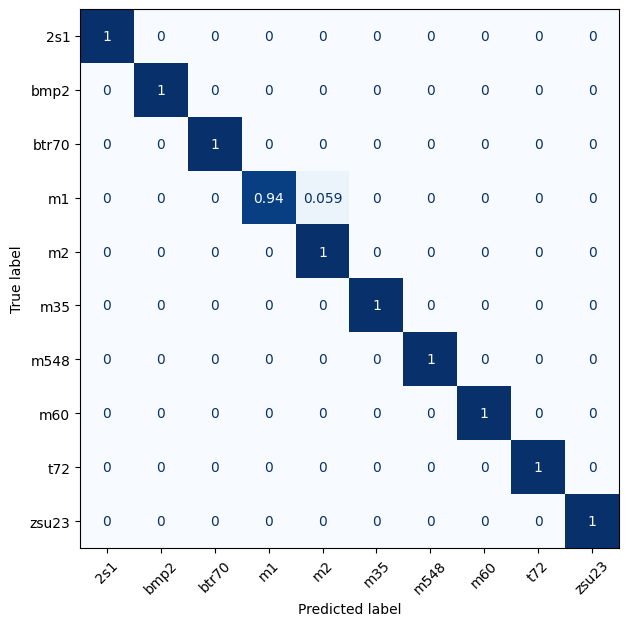

shifted up by 10 units
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)


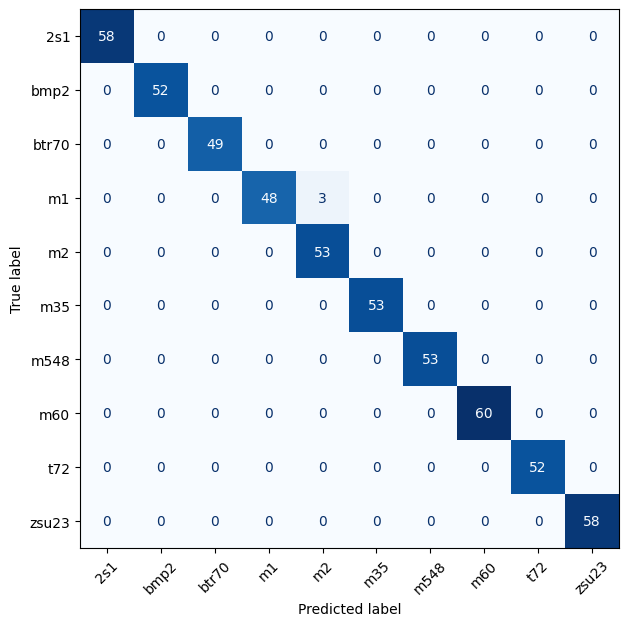

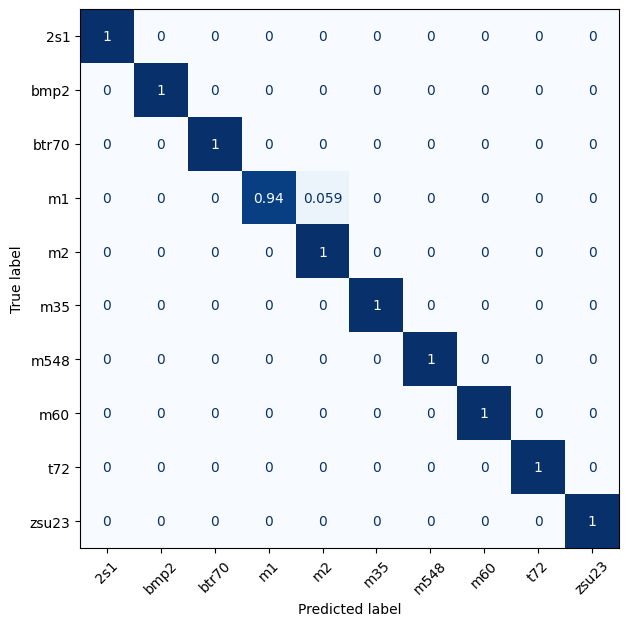

shifted down by 10 units
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)


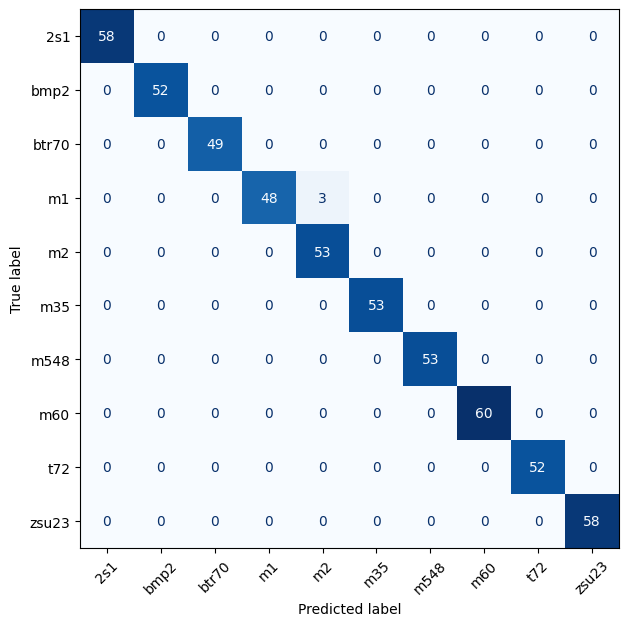

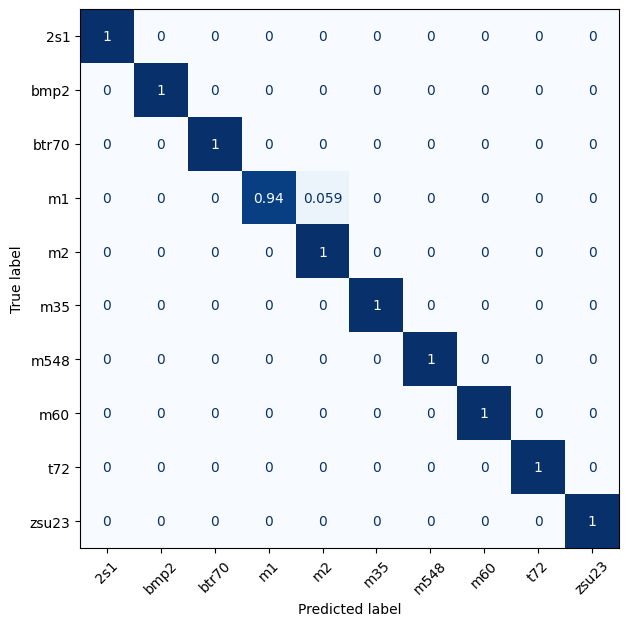

In [16]:
for ds in [test_ds, shifted_left_17, shifted_right_17, shifted_up_17, shifted_down_17]:

    test_dataloader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

    if ds is shifted_left_17:
        print("shifted left by 5 units")
    elif ds is shifted_right_17:
        print("shifted right by 15 units")
    elif ds is shifted_up_17:
        print("shifted up by 10 units")
    elif ds is shifted_down_17:
        print("shifted down by 10 units")
    elif ds is test_ds:
        print("unshifted")

    seed = 666
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    get_logits = get_logits_model('LPSLogitLayers')
    pooling_layer = partial(PolyphaseInvariantDown2D, component_selection=LPS, get_logits=get_logits)
    extras_model = {
            'logits_channels': {"maxpool": 8, "layer2": 16, "layer3": 32, "layer4": 64},
            'conv1_stride': False,
            'maxpool_zpad': False,
            'swap_conv_pool': True,
            'inc_conv1_support': True,
            'apply_maxpool': True,
            'ret_prob': True,
            'forward_pool_method': 'LPS',
        }
        
    new_model = ResNet18Custom(
            input_shape=(3, 128, 128),
            num_classes=len(train_ds.class_to_idx),
            padding_mode='circular',
            pooling_layer=pooling_layer,
            extras_model=extras_model,
        )
    new_model.load_state_dict(torch.load(
            os.path.join(workspace, f"weights/SSR/Extras/LPD/real/rn18_seed{seed}_b16_theirmodel.pth"),
            map_location=device
        ))
    
    new_model = new_model.to(device)
    new_model.eval()
    
    n_test = len(test_ds)
    labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
    preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
    
    idx = 0
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            bs = inputs.size(0)
            labels_tensor[idx:idx+bs] = labels
            preds_tensor[idx:idx+bs] = preds
            idx += bs
    
    _labels_all = labels_tensor.cpu().numpy()
    _preds_all = preds_tensor.cpu().numpy()
    
    cm = confusion_matrix(_labels_all, _preds_all)
    cm_cpu = cp.asnumpy(cm)
    disp = ConfusionMatrixDisplay(cm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.tick_params(axis='x', rotation=45)
    plt.show()
    
    cm_norm = confusion_matrix(_labels_all, _preds_all, normalize='true')
    cm_norm_cpu = cp.asnumpy(cm_norm)
    disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.tick_params(axis='x', rotation=45)
    plt.show()